<a href="https://www.kaggle.com/code/wilfriedtsetse04/neurosight-ai-notebook?scriptVersionId=317655501" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

<a href="https://www.kaggle.com/code/wilfriedtsetse04/neurosight-ai-notebook?scriptVersionId=317477673" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

<a href="https://www.kaggle.com/code/wilfriedtsetse04/neurosight-ai-notebook?scriptVersionId=300807538" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
import os
import sys
import importlib

# 1. Nettoyage et téléchargement du nouveau pipeline
# Remplace par l'URL de ta branche où tu vas pousser le nouveau data_pipeline.py
GITHUB_RAW_URL = "https://raw.githubusercontent.com/wekt2k04/NeuroSight_AI/dev-leila2/notebooks/data_pipeline.py"

print("📥 Mise à jour du pipeline NeuroSight...")
!wget -q -O data_pipeline.py {GITHUB_RAW_URL}

if '/kaggle/working' not in sys.path:
    sys.path.append('/kaggle/working')

# 2. Importation dynamique
try:
    import data_pipeline
    importlib.reload(data_pipeline)
    from data_pipeline import prepare_data, show_sample_batch, plot_class_distribution
    print("✅ Pipeline 'Feature Engineered' chargé avec succès.")
except Exception as e:
    print(f"❌ Erreur d'import : {e}")

📥 Mise à jour du pipeline NeuroSight...
✅ Pipeline 'Feature Engineered' chargé avec succès.


In [2]:
# --- CONFIGURATION DES CHEMINS ---
# Assure-toi que ces chemins correspondent à tes inputs Kaggle
CSV_PATH = '/kaggle/input/datasets/wilfriedtsetse04/mon-csv-officiel/oasis_cross-sectional-5708aa0a98d82080.xlsx'
IMAGES_DIR = '/kaggle/input/datasets/ninadaithal/imagesoasis/Data'

# --- CRÉATION DES LOADERS ---
# Note : on utilise la nouvelle fonction 'prepare_data'

# train_loader, val_loader, test_loader, classes = prepare_data(
#     csv_path=CSV_PATH, 
#     images_dir=IMAGES_DIR, 
#     batch_size=32
# )

# Prepare data with balanced test set
# train_loader, val_loader, test_loader, classes = prepare_data(
#     csv_path=CSV_PATH,
#     images_dir=IMAGES_DIR,
#     batch_size=32,
#     val_split=0.15,
#     test_split=0.15,
#     target_train_per_class=5000,
#     target_test_per_class=50  # Ensures at least 50 Moderate Demented samples in test
# )

# # Verify the test set has all classes
# plot_class_distribution(test_loader, classes)

# The updated prepare_data returns 5 values:
# train_loader, val_loader, test_loader, class_weights, class_names

train_loader, val_loader, test_loader, class_weights, classes = prepare_data(
    csv_path=CSV_PATH,
    images_dir=IMAGES_DIR,
    batch_size=32,
    target_train_per_class=5000,
    target_test_per_class=50,
    class_weight_method='focus'  # 'balanced' or 'focus'
)

print(f"\n📊 Class weights for loss function: {class_weights.numpy()}")
print(f"   Classes: {classes}")

# Then train as before, but evaluate on test_loader at the end

# # --- AUDIT VISUEL ---
# print(f"\n🚀 Classes prêtes : {classes}")
# plot_class_distribution(train_loader, classes)
# show_sample_batch(train_loader, classes)

📖 Loading clinical data + MICE imputation...
   ✅ MICE imputation done.
🔍 Scanning images: /kaggle/input/datasets/ninadaithal/imagesoasis/Data
   ✅ 47580 images linked.

🛡️ Stratified Group Split (patient-level, class-balanced)...

📊 INITIAL SPLIT STATISTICS:
   Train: {0: np.int64(20252), 1: np.int64(10004), 2: np.int64(3599), 3: np.int64(244)}
   Val: {0: np.int64(4087), 1: np.int64(1891), 2: np.int64(671), 3: np.int64(244)}
   Test: {0: np.int64(4026), 1: np.int64(1830), 2: np.int64(732)}

🔄 Ensuring test set has all classes...

   Original test counts: {0: np.int64(4026), 1: np.int64(1830), 2: np.int64(732)}
   Moved 50 samples of class 3 from train to test
   New test counts: {0: np.int64(4026), 1: np.int64(1830), 2: np.int64(732), 3: np.int64(50)}

⚖️ STAGE 1: Balancing TRAIN set to 5000 samples per class...
   Class 0: undersampled from 20252 to 5000
   Class 1: undersampled from 10004 to 5000
   Class 2: oversampled from 3599 to 5000
   Class 3: oversampled from 194 to 5000

  


🖥️ DEVICE: cuda

📊 Class weights for loss function: [0.9302326 0.9302326 1.1162791 1.0232558]
   Classes: ['NonDemented', 'VeryMildDemented', 'MildDemented', 'ModerateDemented']
Downloading: "https://download.pytorch.org/models/efficientnet_b2_rwightman-c35c1473.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b2_rwightman-c35c1473.pth


100%|██████████| 35.2M/35.2M [00:00<00:00, 182MB/s]



🚀 TRAINING NEUROSIGHT MODEL (Optimized for Specificity)
   Dropout: 0.6
   Warmup epochs: 15
   LR Head: 3e-05
   LR Backbone: 3e-07
   Label Smoothing: 0.12

📌 Epoch 1/50
----------------------------------------
Train Loss: 0.7604
Val Loss  : 0.6554
Val Macro-F1: 0.2370
Per-class F1: N=0.500, V=0.314, M=0.079, Mod=0.054
Best F1   : 0.0000
Patience  : 0/8
✅ New best model saved

📌 Epoch 2/50
----------------------------------------
Train Loss: 0.6685
Val Loss  : 0.6109
Val Macro-F1: 0.2502
Per-class F1: N=0.569, V=0.362, M=0.054, Mod=0.016
Best F1   : 0.2370
Patience  : 0/8
✅ New best model saved

📌 Epoch 3/50
----------------------------------------
Train Loss: 0.6362
Val Loss  : 0.6281
Val Macro-F1: 0.2405
Per-class F1: N=0.512, V=0.375, M=0.055, Mod=0.020
Best F1   : 0.2502
Patience  : 0/8

📌 Epoch 4/50
----------------------------------------
Train Loss: 0.6200
Val Loss  : 0.6325
Val Macro-F1: 0.2394
Per-class F1: N=0.480, V=0.390, M=0.068, Mod=0.020
Best F1   : 0.2502
Patience  :

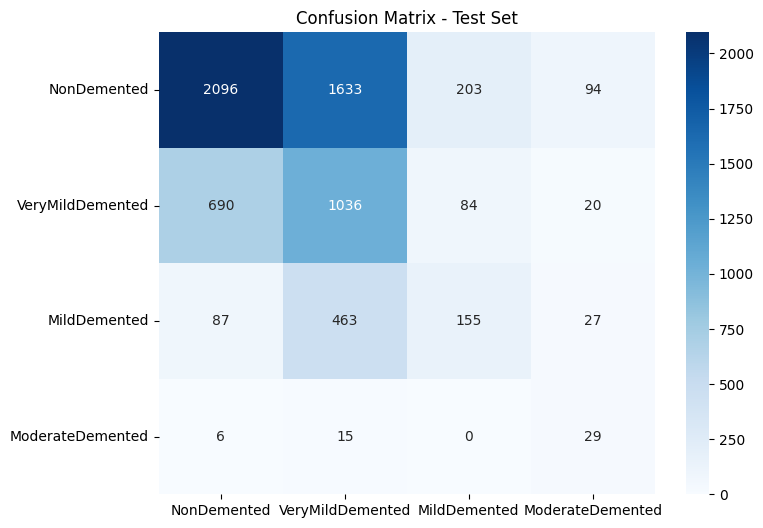

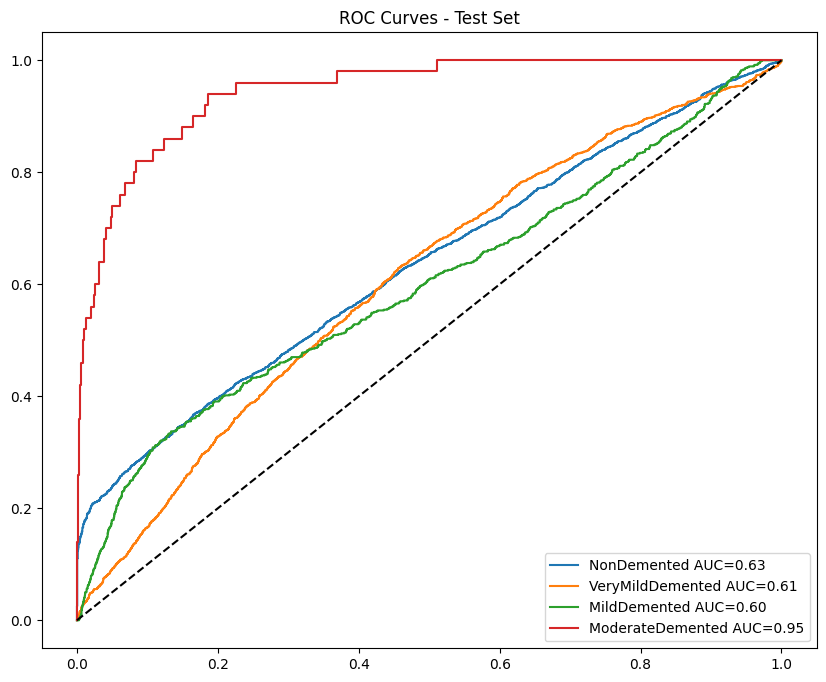


📊 Per-Class Performance:
--------------------------------------------------
NonDemented          | Precision: 0.7280 | Recall: 0.5206 | F1: 0.6071
VeryMildDemented     | Precision: 0.3292 | Recall: 0.5661 | F1: 0.4163
MildDemented         | Precision: 0.3507 | Recall: 0.2117 | F1: 0.2641
ModerateDemented     | Precision: 0.1706 | Recall: 0.5800 | F1: 0.2636
--------------------------------------------------
Macro AVG     | Precision: 0.3946 | Recall: 0.4696 | F1: 0.3878
Weighted AVG  | Precision: 0.5723 | Recall: 0.4995 | F1: 0.5141


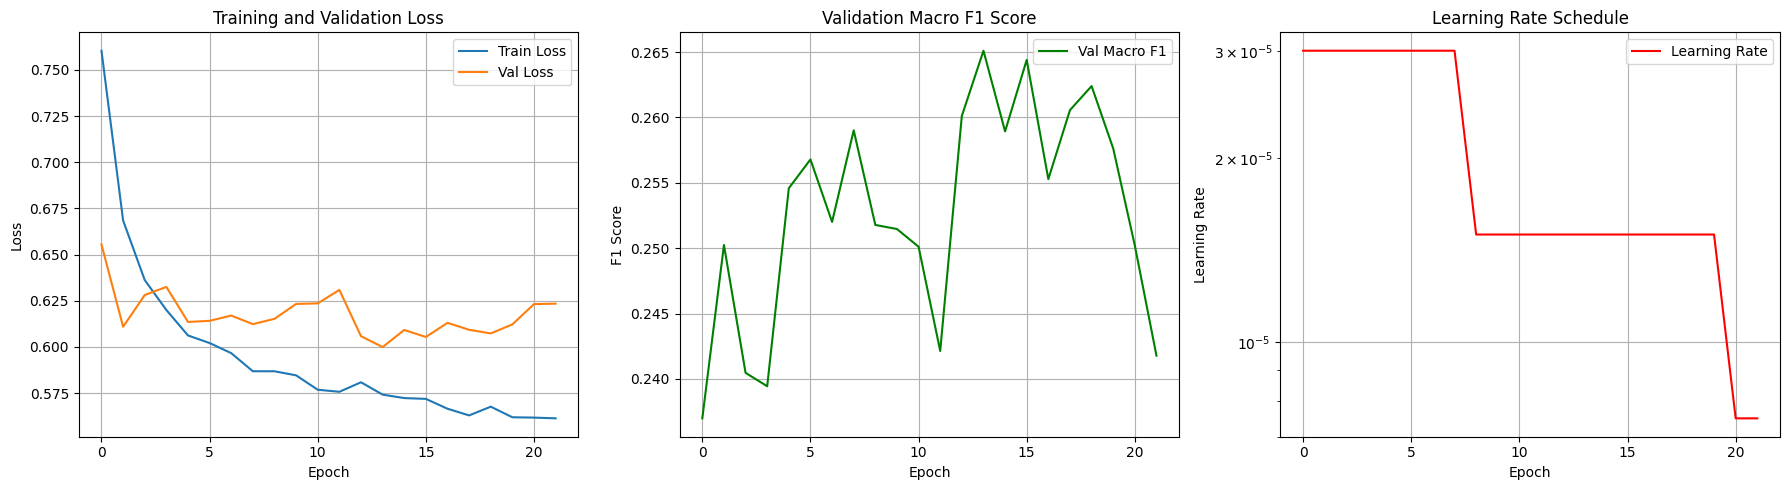


📊 Optimal Thresholds for Each Class:
   NonDemented: 0.30
   VeryMildDemented: 0.30
   MildDemented: 0.30
   ModerateDemented: 0.30

✅ Model saved to 'neurosight_model_optimized.pth'


In [3]:
# ==========================================================
# CELLULE 3 : ENTRAÎNEMENT & AUDIT DES MÉTRIQUES (ADJUSTED VERSION)
# Optimized for better specificity - Stage 1 Only
# ==========================================================
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, f1_score, recall_score
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import copy
from torch.optim.lr_scheduler import ReduceLROnPlateau
import torch.nn.functional as F


# ==========================================================
# FOCAL LOSS WITH CLASS WEIGHTS
# ==========================================================
class WeightedFocalLoss(nn.Module):
    def __init__(self, class_weights=None, gamma=2.0, label_smoothing=0.05):
        super().__init__()
        self.gamma = gamma
        self.ls = label_smoothing
        self.class_weights = class_weights

    def forward(self, logits, targets):
        if self.class_weights is not None:
            device = logits.device
            class_weights = self.class_weights.to(device)
        else:
            class_weights = None
            
        ce = F.cross_entropy(
            logits,
            targets,
            reduction='none',
            weight=class_weights,
            label_smoothing=self.ls
        )
        pt = torch.exp(-ce)
        focal_weight = (1 - pt) ** self.gamma
        return (focal_weight * ce).mean()


# ==========================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\n🖥️ DEVICE: {device}")


# ==========================================================
# MODEL - MODERATE DROPOUT (reduced from 0.8)
# ==========================================================
def build_neurosight_model(num_classes, dropout=0.6):
    model = models.efficientnet_b2(weights=models.EfficientNet_B2_Weights.IMAGENET1K_V1)
    
    for p in model.parameters():
        p.requires_grad = False

    in_f = model.classifier[1].in_features

    model.classifier = nn.Sequential(
        nn.Dropout(dropout),
        nn.Linear(in_f, 512),
        nn.BatchNorm1d(512),
        nn.ReLU(inplace=True),
        nn.Dropout(dropout / 2),
        nn.Linear(512, num_classes),
    )
    return model.to(device)


def unfreeze_top_blocks(model, num_blocks=1):
    layers = list(model.features.children())
    for layer in layers[-num_blocks:]:
        for p in layer.parameters():
            p.requires_grad = True


# ==========================================================
# TRAINING LOOP (STAGE 1 ONLY - NO STAGE 2)
# ==========================================================
def train_model(model, train_loader, val_loader, class_weights,
                num_epochs=50,
                warmup_epochs=15,
                patience=8,
                lr_head=3e-5,
                lr_backbone=3e-7,
                label_smoothing=0.12):

    print("\n🚀 TRAINING NEUROSIGHT MODEL (Optimized for Specificity)")
    print("=" * 60)
    print(f"   Dropout: 0.6")
    print(f"   Warmup epochs: {warmup_epochs}")
    print(f"   LR Head: {lr_head}")
    print(f"   LR Backbone: {lr_backbone}")
    print(f"   Label Smoothing: {label_smoothing}")
    print("=" * 60)

    class_weights = class_weights.to(device)
    criterion = WeightedFocalLoss(class_weights=class_weights, gamma=2.0, label_smoothing=label_smoothing)

    optimizer = optim.AdamW([
        {'params': model.classifier.parameters(), 'lr': lr_head, 'weight_decay': 1e-4},
        {'params': model.features.parameters(), 'lr': 0.0, 'weight_decay': 1e-4},
    ], weight_decay=1e-4)

    scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

    best_f1 = 0.0
    best_weights = None
    epochs_no_improve = 0

    history = {"train_loss": [], "val_loss": [], "val_f1": [], "learning_rates": []}

    for epoch in range(num_epochs):
        if epoch == warmup_epochs:
            print("\n🔓 UNFREEZING BACKBONE")
            unfreeze_top_blocks(model, num_blocks=1)
            optimizer.param_groups[1]['lr'] = lr_backbone
            print(f"   Backbone LR set to: {lr_backbone}")

        print(f"\n📌 Epoch {epoch+1}/{num_epochs}")
        print("-" * 40)

        model.train()
        train_loss = 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            train_loss += loss.item()
        avg_train_loss = train_loss / len(train_loader)

        model.eval()
        val_loss = 0
        all_preds, all_labels = [], []
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                preds = outputs.argmax(1)
                val_loss += loss.item()
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

        avg_val_loss = val_loss / len(val_loader)
        val_f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
        per_class_f1 = f1_score(all_labels, all_preds, average=None, zero_division=0)

        history["train_loss"].append(avg_train_loss)
        history["val_loss"].append(avg_val_loss)
        history["val_f1"].append(val_f1)
        history["learning_rates"].append(optimizer.param_groups[0]['lr'])

        print(f"Train Loss: {avg_train_loss:.4f}")
        print(f"Val Loss  : {avg_val_loss:.4f}")
        print(f"Val Macro-F1: {val_f1:.4f}")
        print(f"Per-class F1: N={per_class_f1[0]:.3f}, V={per_class_f1[1]:.3f}, M={per_class_f1[2]:.3f}, Mod={per_class_f1[3]:.3f}")
        print(f"Best F1   : {best_f1:.4f}")
        print(f"Patience  : {epochs_no_improve}/{patience}")

        if val_f1 > best_f1:
            best_f1 = val_f1
            best_weights = copy.deepcopy(model.state_dict())
            torch.save(best_weights, "best_neurosight.pth")
            epochs_no_improve = 0
            print("✅ New best model saved")
        else:
            epochs_no_improve += 1

        scheduler.step(avg_val_loss)
        
        current_lr = optimizer.param_groups[0]['lr']
        if len(history["learning_rates"]) > 1 and current_lr != history["learning_rates"][-2]:
            print(f"📉 Learning rate reduced to: {current_lr}")

        if epochs_no_improve >= patience:
            print("\n🛑 EARLY STOPPING TRIGGERED")
            break

    if best_weights is not None:
        model.load_state_dict(best_weights)
    
    return model, history


# ==========================================================
# EVALUATION FUNCTION
# ==========================================================
def evaluate_on_test(model, test_loader, class_names, thresholds=None):
    print("\n📋 FINAL CLINICAL REPORT - TEST SET")
    print("=" * 60)

    model.eval()
    y_true, y_pred, y_probs = [], [], []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            preds = outputs.argmax(1)
            y_true.extend(labels.numpy())
            y_pred.extend(preds.cpu().numpy())
            y_probs.extend(probs.cpu().numpy())

    y_probs = np.array(y_probs)

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title("Confusion Matrix - Test Set")
    plt.show()

    y_true_bin = label_binarize(y_true, classes=range(len(class_names)))
    plt.figure(figsize=(10, 8))
    for i in range(len(class_names)):
        if np.sum(y_true_bin[:, i]) > 0:
            fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_probs[:, i])
            roc_auc = auc(fpr, tpr)
            plt.plot(fpr, tpr, label=f"{class_names[i]} AUC={roc_auc:.2f}")
    plt.plot([0, 1], [0, 1], 'k--')
    plt.title("ROC Curves - Test Set")
    plt.legend()
    plt.show()
    
    from sklearn.metrics import precision_recall_fscore_support
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average=None, zero_division=0)
    
    print("\n📊 Per-Class Performance:")
    print("-" * 50)
    for i, name in enumerate(class_names):
        print(f"{name:20} | Precision: {precision[i]:.4f} | Recall: {recall[i]:.4f} | F1: {f1[i]:.4f}")
    
    macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='macro', zero_division=0
    )
    weighted_precision, weighted_recall, weighted_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='weighted', zero_division=0
    )
    
    print("-" * 50)
    print(f"Macro AVG     | Precision: {macro_precision:.4f} | Recall: {macro_recall:.4f} | F1: {macro_f1:.4f}")
    print(f"Weighted AVG  | Precision: {weighted_precision:.4f} | Recall: {weighted_recall:.4f} | F1: {weighted_f1:.4f}")
    
    return y_true, y_pred, y_probs


# ==========================================================
# OPTIMIZE THRESHOLDS (Class-specific)
# ==========================================================
def optimize_thresholds(model, val_loader, class_names):
    """Find optimal confidence thresholds for each class"""
    print("\n🎯 OPTIMIZING CLASS THRESHOLDS")
    print("=" * 60)
    
    model.eval()
    all_probs, all_labels = [], []
    
    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.numpy())
    
    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels)
    
    best_thresholds = []
    for i, name in enumerate(class_names):
        best_f1 = 0
        best_thresh = 0.5
        
        # Search for optimal threshold
        for thresh in np.arange(0.3, 0.8, 0.05):
            preds = (all_probs[:, i] > thresh).astype(int)
            true = (all_labels == i).astype(int)
            f1 = f1_score(true, preds, zero_division=0)
            if f1 > best_f1:
                best_f1 = f1
                best_thresh = thresh
        
        best_thresholds.append(best_thresh)
        print(f"{name:20}: threshold={best_thresh:.2f}, F1={best_f1:.3f}")
    
    return best_thresholds


# ==========================================================
# PLOT TRAINING HISTORY
# ==========================================================
def plot_training_history(history):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    axes[0].plot(history['train_loss'], label='Train Loss')
    axes[0].plot(history['val_loss'], label='Val Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('Training and Validation Loss')
    axes[0].legend()
    axes[0].grid(True)
    
    axes[1].plot(history['val_f1'], label='Val Macro F1', color='green')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('F1 Score')
    axes[1].set_title('Validation Macro F1 Score')
    axes[1].legend()
    axes[1].grid(True)
    
    axes[2].plot(history['learning_rates'], label='Learning Rate', color='red')
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('Learning Rate')
    axes[2].set_title('Learning Rate Schedule')
    axes[2].set_yscale('log')
    axes[2].legend()
    axes[2].grid(True)
    
    plt.tight_layout()
    plt.show()


# ==========================================================
# MAIN EXECUTION
# ==========================================================

# First, load your data
# train_loader, val_loader, test_loader, class_weights, classes = prepare_data(...)

print(f"\n📊 Class weights for loss function: {class_weights.numpy()}")
print(f"   Classes: {classes}")

# Build model with MODERATE dropout (0.6 instead of 0.8)
model = build_neurosight_model(len(classes), dropout=0.6)

# Train model (Stage 1 only - no Stage 2)
model, history = train_model(
    model,
    train_loader,
    val_loader,
    class_weights,
    num_epochs=50,
    warmup_epochs=15,
    patience=8,
    lr_head=3e-5,
    lr_backbone=3e-7,
    label_smoothing=0.12
)

# Optimize thresholds
best_thresholds = optimize_thresholds(model, val_loader, classes)

# Final evaluation on test set
print("\n" + "="*60)
print("FINAL EVALUATION ON HELD-OUT TEST SET")
print("="*60)

y_true, y_pred, y_probs = evaluate_on_test(model, test_loader, classes)

# Plot training history
plot_training_history(history)

# Print best thresholds
print("\n📊 Optimal Thresholds for Each Class:")
for i, name in enumerate(classes):
    print(f"   {name}: {best_thresholds[i]:.2f}")

# Save model
torch.save({
    'model_state_dict': model.state_dict(),
    'history': history,
    'class_names': classes,
    'best_thresholds': best_thresholds,
}, 'neurosight_model_optimized.pth')
print("\n✅ Model saved to 'neurosight_model_optimized.pth'")

In [4]:
# ==========================================================
# LOAD TRAINED MODEL (NO RETRAINING)
# ==========================================================
import torch
import torch.nn as nn
from torchvision import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Same architecture as training
def build_neurosight_model(num_classes, dropout=0.6):
    model = models.efficientnet_b2(
        weights=models.EfficientNet_B2_Weights.IMAGENET1K_V1
    )

    in_f = model.classifier[1].in_features

    model.classifier = nn.Sequential(
        nn.Dropout(dropout),
        nn.Linear(in_f, 512),
        nn.BatchNorm1d(512),
        nn.ReLU(inplace=True),
        nn.Dropout(dropout / 2),
        nn.Linear(512, num_classes),
    )

    return model


# IMPORTANT:
# Put your real class list here
classes = [
    'NonDemented',
    'VeryMildDemented',
    'MildDemented',
    'ModerateDemented'
]
num_classes = len(classes)

# Build model
model = build_neurosight_model(num_classes)

# Load saved weights
model.load_state_dict(
    torch.load(
        "/kaggle/working/best_neurosight.pth",
        map_location=device
    )
)

model = model.to(device)
model.eval()

print("✅ Trained model loaded successfully")

✅ Trained model loaded successfully



🔥 Generating Grad-CAM Visualizations...


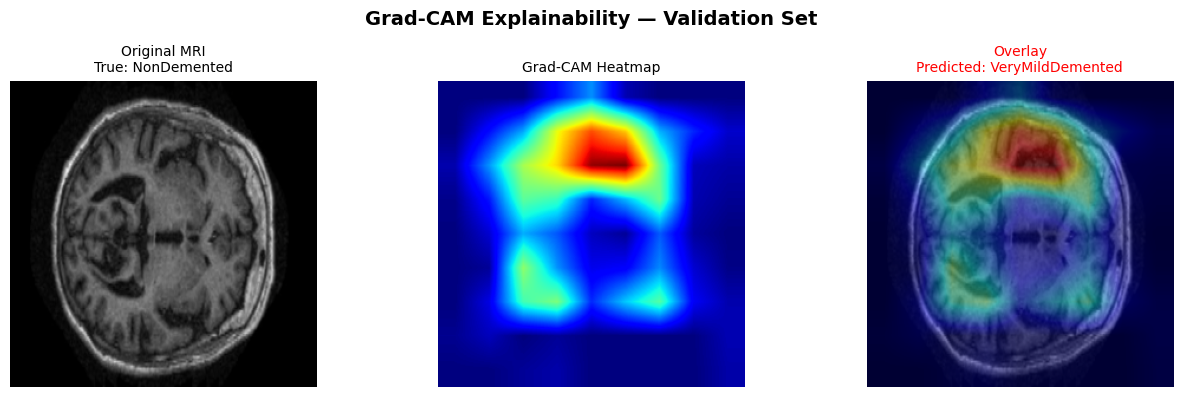


✅ Grad-CAM saved to:
/kaggle/working/gradcam_visualization.png


In [5]:
# ==========================================================
# CELLULE 7 : GRAD-CAM — VISUALISATION EXPLICABLE (XAI)
# Compatible EfficientNet-B2
# ==========================================================
import torch
import numpy as np
import matplotlib.pyplot as plt
import cv2

class GradCAM:
    """
    Grad-CAM using forward + backward hooks
    """

    def __init__(self, model, target_layer):
        self.model = model
        self.activations = None
        self.gradients = None

        self._fwd_hook = target_layer.register_forward_hook(
            self._save_activation
        )

        self._bwd_hook = target_layer.register_full_backward_hook(
            self._save_gradient
        )

    def _save_activation(self, module, input, output):
        self.activations = output.detach()

    def _save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, input_tensor, class_idx=None):

        self.model.eval()

        output = self.model(input_tensor)

        if class_idx is None:
            class_idx = output.argmax(dim=1).item()

        self.model.zero_grad()

        output[0, class_idx].backward()

        # Global Average Pooling on gradients
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)

        # Weighted sum of activations
        cam = (weights * self.activations).sum(dim=1)

        # ReLU
        cam = torch.relu(cam)

        cam = cam.squeeze().cpu().numpy()

        # Normalize
        cam_min = cam.min()
        cam_max = cam.max()

        if cam_max - cam_min > 1e-8:
            cam = (cam - cam_min) / (cam_max - cam_min)
        else:
            cam = np.zeros_like(cam)

        return cam, class_idx

    def remove_hooks(self):
        self._fwd_hook.remove()
        self._bwd_hook.remove()


def visualize_gradcam(model, val_loader, class_names, device, num_samples=4):

    print("\n🔥 Generating Grad-CAM Visualizations...")
    print("=" * 60)

    # ------------------------------------------------------
    # TARGET LAYER (EfficientNet-B2)
    # ------------------------------------------------------
    target_layer = model.features[-1]

    gradcam = GradCAM(model, target_layer)

    # ------------------------------------------------------
    # ImageNet normalization values
    # ------------------------------------------------------
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    # ------------------------------------------------------
    # Get validation batch
    # ------------------------------------------------------
    images, labels = next(iter(val_loader))

    indices = []
    seen_classes = set()

    for i, lbl in enumerate(labels):
        cls = lbl.item()

        if cls not in seen_classes:
            seen_classes.add(cls)
            indices.append(i)

        if len(indices) >= num_samples:
            break

    # ------------------------------------------------------
    # Plot setup
    # ------------------------------------------------------
    fig, axes = plt.subplots(
        len(indices),
        3,
        figsize=(13, 4 * len(indices))
    )

    if len(indices) == 1:
        axes = [axes]

    # ------------------------------------------------------
    # Process each sample
    # ------------------------------------------------------
    for row, idx in enumerate(indices):

        input_tensor = images[idx].unsqueeze(0).to(device)

        # Generate CAM
        cam, pred_idx = gradcam.generate(input_tensor)

        # Original image
        img_np = images[idx].cpu().numpy().transpose(1, 2, 0)

        # De-normalize
        img_np = np.clip(img_np * std + mean, 0, 1)

        # Convert to uint8
        img_u8 = (img_np * 255).astype(np.uint8)

        # Resize CAM to image size
        h, w = img_u8.shape[:2]

        cam_resized = cv2.resize(cam, (w, h))

        # Heatmap
        heatmap = cv2.applyColorMap(
            np.uint8(cam_resized * 255),
            cv2.COLORMAP_JET
        )

        heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

        # Overlay
        overlay = cv2.addWeighted(
            img_u8,
            0.6,
            heatmap,
            0.4,
            0
        )

        true_label = class_names[labels[idx].item()]
        pred_label = class_names[pred_idx]

        color = "green" if pred_idx == labels[idx].item() else "red"

        # --------------------------------------------------
        # Column 1 : Original MRI
        # --------------------------------------------------
        axes[row][0].imshow(img_np)
        axes[row][0].set_title(
            f"Original MRI\nTrue: {true_label}",
            fontsize=10
        )

        # --------------------------------------------------
        # Column 2 : CAM
        # --------------------------------------------------
        axes[row][1].imshow(cam_resized, cmap='jet')
        axes[row][1].set_title(
            "Grad-CAM Heatmap",
            fontsize=10
        )

        # --------------------------------------------------
        # Column 3 : Overlay
        # --------------------------------------------------
        axes[row][2].imshow(overlay)
        axes[row][2].set_title(
            f"Overlay\nPredicted: {pred_label}",
            fontsize=10,
            color=color
        )

        for ax in axes[row]:
            ax.axis("off")

    gradcam.remove_hooks()

    plt.suptitle(
        "Grad-CAM Explainability — Validation Set",
        fontsize=14,
        fontweight='bold'
    )

    plt.tight_layout()

    save_path = "/kaggle/working/gradcam_visualization.png"

    plt.savefig(
        save_path,
        dpi=150,
        bbox_inches='tight'
    )

    plt.show()

    print(f"\n✅ Grad-CAM saved to:")
    print(save_path)


# ==========================================================
# RUN GRAD-CAM
# ==========================================================
visualize_gradcam(
    model=model,
    val_loader=val_loader,
    class_names=classes,
    device=device,
    num_samples=4
)

In [6]:
!pip install --quiet onnx onnxruntime onnxscript

import torch
import onnx
import onnxruntime as ort
import numpy as np

ONNX_PATH = "/kaggle/working/neurosight_model.onnx"

IMAGE_SIZE = 224

model.eval()

dummy_input = torch.randn(
    1,
    3,
    IMAGE_SIZE,
    IMAGE_SIZE
).to(device)

torch.onnx.export(
    model,
    dummy_input,
    ONNX_PATH,
    export_params=True,
    opset_version=17,
    do_constant_folding=True,
    input_names=['mri_input'],
    output_names=['class_logits'],
    dynamic_axes={
        'mri_input': {0: 'batch_size'},
        'class_logits': {0: 'batch_size'}
    }
)

print("✅ ONNX export successful")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 92.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 714.8/714.8 kB 43.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.8/166.8 kB 14.7 MB/s eta 0:00:00


/tmp/ipykernel_22/485277133.py:21: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0508 15:58:40.865000 22 torch/onnx/_internal/exporter/_compat.py:125] Setting ONNX exporter to use operator set version 18 because the requested opset_version 17 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features
W0508 15:58:41.875000 22 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, rois, spatial_scale: 'float', pooled_height: 'int', pooled_width: 'int', sampling_ratio: 'int' = -1, al

[torch.onnx] Obtain model graph for `EfficientNet([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `EfficientNet([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...


The model version conversion is not supported by the onnxscript version converter and fallback is enabled. The model will be converted using the onnx C API (target version: 17).


[torch.onnx] Translate the graph into ONNX... ✅


Failed to convert the model to the target version 17 using the ONNX C API. The model was not modified
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 137, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 132, in _partial_convert_version
    return onnx.version_converter.convert_version(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnx/version_converter.py", line 39, in convert_version
    converted_model_str = C.convert_version(model_str, target_version)
                          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
Runtim

✅ ONNX export successful


In [7]:
import onnx
import onnxruntime as ort

ONNX_PATH = "/kaggle/working/neurosight_model.onnx"

# Load model
onnx_model = onnx.load(ONNX_PATH)

# Validate graph
onnx.checker.check_model(onnx_model)

print("✅ ONNX graph is VALID")

# Show opset version
print("\n📦 ONNX Opset Version:")
print(onnx_model.opset_import[0].version)

# Test inference session
ort_session = ort.InferenceSession(
    ONNX_PATH,
    providers=['CPUExecutionProvider']
)

print("\n✅ ONNX Runtime loaded model successfully")

✅ ONNX graph is VALID

📦 ONNX Opset Version:
18

✅ ONNX Runtime loaded model successfully
